### Support Vector Machine (SVM)

Como primer modelo de clasificación se seleccionó Support Vector Machine (SVM), un algoritmo ampliamente utilizado por su capacidad para encontrar fronteras de decisión robustas entre clases y por su buen desempeño en conjuntos de datos con características numéricas. En este proyecto, las imágenes fueron representadas mediante variables geométricas y de color, como área, relación de aspecto y estadísticas del espacio HSV, lo que hace que SVM sea una alternativa adecuada para evaluar la capacidad predictiva de estas características.

Además, SVM suele ofrecer una buena capacidad de generalización y puede modelar relaciones complejas entre variables mediante el uso de kernels, convirtiéndolo en un candidato sólido para la clasificación de la calidad de frutas en categorías de calidad.


### Librerías

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                            cohen_kappa_score, matthews_corrcoef, 
                            confusion_matrix, classification_report,
                            balanced_accuracy_score, roc_auc_score,
                            precision_recall_curve, average_precision_score, roc_curve)
import json
import joblib

models_dir = Path("..") / "models"
models_dir.mkdir(exist_ok=True)
svm_quality_path = models_dir / 'svm_quality.pkl'
svm_size_path = models_dir / 'svm_size.pkl'

COLOR_PRIMARY = '#FF5E8A'
COLOR_SECONDARY = '#FF8FAB'
COLOR_TERTIARY = '#FFB7C9'
COLOR_DARK = '#D43F6B'
COLOR_LIGHT = '#FFE4EC'

sns.set_style("whitegrid")
sns.set_palette([COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY, COLOR_DARK])
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

### Análisis del dataset

In [2]:
BASE_DIR = Path("..") / "data"
ANNOTATIONS_DIR = BASE_DIR / "annotations"
OUTPUT_CSV = ANNOTATIONS_DIR / "preprocessed_metadata.csv"

df = pd.read_csv(OUTPUT_CSV)
print(f"Total de muestras: {len(df)}")
print(f"Columnas disponibles: {df.columns.tolist()[:15]}...")

Total de muestras: 36848
Columnas disponibles: ['original_image', 'quality', 'fruit', 'crop_path', 'x', 'y', 'width_px', 'height_px', 'area_px', 'aspect_ratio', 'num_fruits_in_image', 'relative_size_in_image', 'coverage_ratio', 'img_width', 'img_height']...


In [3]:
print("DISTRIBUCIÓN DE CLASES")
print("\nCalidad:")
print(df['quality'].value_counts())
print("\nTamaño:")
print(df['size_category'].value_counts())

feature_cols = [
    'area_px', 'aspect_ratio', 'coverage_ratio',
    'hue_mean', 'saturation_mean', 'value_mean',
    'hue_std', 'saturation_std', 'value_std'
]

available_features = [col for col in feature_cols if col in df.columns]
feature_cols = available_features
print(f"Características a usar ({len(feature_cols)}): {feature_cols}")

DISTRIBUCIÓN DE CLASES

Calidad:
quality
good       14966
bad        11346
regular    10536
Name: count, dtype: int64

Tamaño:
size_category
grande     14511
mediano    12053
pequeño    10284
Name: count, dtype: int64
Características a usar (9): ['area_px', 'aspect_ratio', 'coverage_ratio', 'hue_mean', 'saturation_mean', 'value_mean', 'hue_std', 'saturation_std', 'value_std']


Tenemos que, las tres clases presentan una distribución relativamente balanceada, aunque `good` es la clase mayoritaria y `regular` la minoritaria, y como vimos en el EDA, existe un ligero predominio de frutas `grandes`, pero no se observa un desbalance severo entre categorías. Finalmente, se utilizarán 9 características que combinan información geométrica (tamaño y forma) y cromática (color y variabilidad del color) para la clasificación.


### Entrenamiento del modelo

In [4]:
# Preparar datos
X = df[feature_cols].fillna(0)
y_quality = df['quality']
y_size = df['size_category']

le_quality = LabelEncoder()
le_size = LabelEncoder()

y_quality_encoded = le_quality.fit_transform(y_quality)
y_size_encoded = le_size.fit_transform(y_size)

print(f"Clases calidad: {dict(zip(le_quality.classes_, range(len(le_quality.classes_))))}")
print(f"Clases tamaño: {dict(zip(le_size.classes_, range(len(le_size.classes_))))}")

# División estratificada
X_train, X_test, y_quality_train, y_quality_test, y_size_train, y_size_test = train_test_split(
    X, y_quality_encoded, y_size_encoded, test_size=0.2, random_state=42, 
    stratify=y_quality_encoded
)

print(f"Entrenamiento: {len(X_train)} muestras")
print(f"Prueba: {len(X_test)} muestras")
print(f"\nCaracterísticas: {X_train.shape[1]}")

Clases calidad: {'bad': 0, 'good': 1, 'regular': 2}
Clases tamaño: {'grande': 0, 'mediano': 1, 'pequeño': 2}
Entrenamiento: 29478 muestras
Prueba: 7370 muestras

Características: 9


Se construyó un pipeline compuesto por una etapa de normalización de las características mediante StandardScaler y un clasificador SVM configurado para compensar posibles desbalances entre clases (class_weight='balanced'). 

Posteriormente, se evaluó el modelo utilizando validación cruzada estratificada de 5 particiones, preservando la proporción de cada clase en todos los subconjuntos. El desempeño se midió mediante la métrica F1-Macro, obteniendo una estimación robusta de la capacidad de generalización del modelo antes de realizar el ajuste de hiperparámetros.

In [5]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("VALIDACIÓN CRUZADA INICIAL (parámetros por defecto)")
cv_scores = cross_val_score(svm_pipeline, X_train, y_quality_train, cv=cv, scoring='f1_macro')
print(f"F1-Macro CV: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

VALIDACIÓN CRUZADA INICIAL (parámetros por defecto)
F1-Macro CV: 0.8244 (+/- 0.0046)


El modelo obtuvo un F1-Macro promedio de 0.8244, con una variación muy baja entre particiones (±0.0046), lo que indica un rendimiento sólido y estable sobre los datos de entrenamiento.

#### Optimización de hiperparámetros

Con el objetivo de mejorar el desempeño del clasificador SVM, se realizó una búsqueda de hiperparámetros utilizando validación cruzada estratificada de 3 particiones y la métrica F1-Macro como criterio de evaluación. Se exploraron diferentes combinaciones de los parámetros C y gamma para un núcleo radial (RBF), evaluando un total de nueve configuraciones.


BÚSQUEDA DE HIPERPARÁMETROS
Total combinaciones: 9

Optimizando SVM para calidad...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Mejores parámetros para calidad:
   C: 10
   gamma: 1
   Mejor F1-Macro CV: 0.8671

Optimizando SVM para tamaño...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Mejores parámetros para tamaño:
   C: 10
   gamma: 1
   Mejor F1-Macro CV: 0.9208


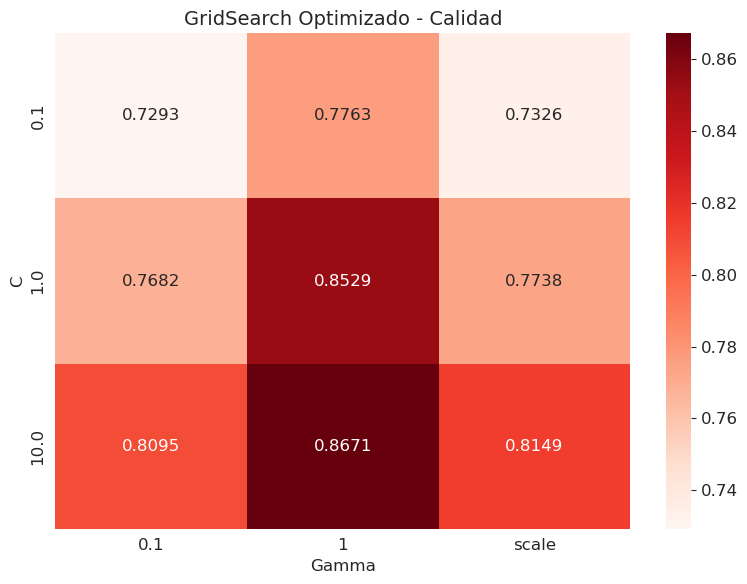

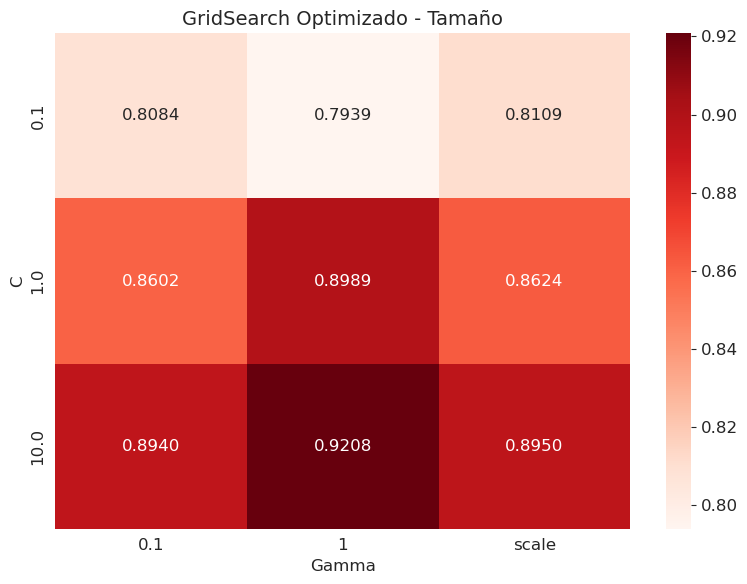

In [8]:
param_grid_reduced = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1, 1],
    'svm__kernel': ['rbf']
}

print("BÚSQUEDA DE HIPERPARÁMETROS")
print(f"Total combinaciones: 9")

print("\nOptimizando SVM para calidad...")

random_search_quality = RandomizedSearchCV(
    svm_pipeline,
    param_distributions=param_grid_reduced,
    n_iter=9,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search_quality.fit(X_train[:5000], y_quality_train[:5000])

print(f"\nMejores parámetros para calidad:")
print(f"   C: {random_search_quality.best_params_['svm__C']}")
print(f"   gamma: {random_search_quality.best_params_['svm__gamma']}")
print(f"   Mejor F1-Macro CV: {random_search_quality.best_score_:.4f}")

print("\nOptimizando SVM para tamaño...")

random_search_size = RandomizedSearchCV(
    svm_pipeline,
    param_distributions=param_grid_reduced,
    n_iter=9,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search_size.fit(X_train[:5000], y_size_train[:5000])

print(f"\nMejores parámetros para tamaño:")
print(f"   C: {random_search_size.best_params_['svm__C']}")
print(f"   gamma: {random_search_size.best_params_['svm__gamma']}")
print(f"   Mejor F1-Macro CV: {random_search_size.best_score_:.4f}")


def plot_simple_heatmap(results, title="Resultados Búsqueda"):
    df_results = pd.DataFrame(results.cv_results_)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    pivot = df_results.pivot_table(
        values='mean_test_score',
        index='param_svm__C',
        columns='param_svm__gamma'
    )
    
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Reds', ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Gamma')
    ax.set_ylabel('C')
    plt.tight_layout()
    plt.show()

plot_simple_heatmap(random_search_quality, "GridSearch Optimizado - Calidad")
plot_simple_heatmap(random_search_size, "GridSearch Optimizado - Tamaño")

Los resultados obtenidos evidencian que el desempeño del modelo depende significativamente de la interacción entre ambos hiperparámetros. En las dos tareas de clasificación evaluadas, los mejores resultados se alcanzaron con los valores más altos considerados en la búsqueda (C = 10 y gamma = 1). Este comportamiento sugiere que el problema requiere fronteras de decisión más complejas y una mayor capacidad de separación entre clases.

Para la clasificación de calidad, el modelo alcanzó un valor de **F1-Macro de 0.8671**, mostrando una mejora considerable respecto al modelo base y una adecuada capacidad para distinguir entre las diferentes categorías de calidad. Por su parte, la clasificación de tamaño obtuvo un **F1-Macro de 0.9208**, convirtiéndose en la tarea con mejor desempeño. Este resultado indica que las características utilizadas para representar el tamaño de las frutas proporcionan una separación clara entre las categorías definidas.

Los mapas de calor generados a partir de los resultados de validación cruzada permitieron visualizar el comportamiento del modelo ante distintas combinaciones de hiperparámetros. Además de identificar la configuración óptima, estos gráficos muestran una evolución consistente del rendimiento entre configuraciones vecinas, lo que sugiere un proceso de optimización estable y sin evidencias de sobreajuste abrupto. A partir de este procedimiento se obtuvieron los hiperparámetros utilizados para entrenar los modelos finales de SVM.

Ahora, en esta etapa se construyen los modelos finales de SVM para la clasificación de calidad y tamaño: Primero se verifica si existen modelos previamente entrenados y almacenados. En caso afirmativo, se cargan directamente para evitar reentrenamientos innecesarios. Si no existen, se entrenan nuevos modelos utilizando los mejores hiperparámetros encontrados durante la fase de optimización. 

Finalmente, se generan las predicciones y las probabilidades asociadas sobre el conjunto de prueba para realizar la evaluación del desempeño.

In [25]:
# Verificar si los modelos ya existen
if svm_quality_path.exists() and svm_size_path.exists():
    print("Cargando modelos guardados...")
    final_svm_quality = joblib.load(svm_quality_path)
    final_svm_size = joblib.load(svm_size_path)
    
    # Generar predicciones
    y_quality_pred = final_svm_quality.predict(X_test)
    y_quality_proba = final_svm_quality.predict_proba(X_test)
    y_size_pred = final_svm_size.predict(X_test)
    y_size_proba = final_svm_size.predict_proba(X_test)
    
    print("Predicciones generadas desde modelos cargados")
    
else:
    print("No se encontraron modelos guardados. Entrenando desde cero...")
    
    # Entrenar modelo final para calidad
    best_C = random_search_quality.best_params_['svm__C']
    best_gamma = random_search_quality.best_params_['svm__gamma']
    
    final_svm_quality = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(C=best_C, gamma=best_gamma, kernel='rbf', 
                    random_state=42, class_weight='balanced', probability=True))
    ])
    final_svm_quality.fit(X_train, y_quality_train)
    
    # Entrenar modelo final para tamaño
    best_C_size = random_search_size.best_params_['svm__C']
    best_gamma_size = random_search_size.best_params_['svm__gamma']
    
    final_svm_size = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(C=best_C_size, gamma=best_gamma_size, kernel='rbf',
                    random_state=42, class_weight='balanced', probability=True))
    ])
    final_svm_size.fit(X_train, y_size_train)
    
    # Generar predicciones
    y_quality_pred = final_svm_quality.predict(X_test)
    y_quality_proba = final_svm_quality.predict_proba(X_test)
    y_size_pred = final_svm_size.predict(X_test)
    y_size_proba = final_svm_size.predict_proba(X_test)
    
    print("Modelos entrenados, predicciones generadas y guardados")

Cargando modelos guardados...
Predicciones generadas desde modelos cargados


### Evaluación del modelo

Una vez identificada la mejor configuración de hiperparámetros mediante validación cruzada ((C = 10), (\gamma = 1)), se evaluó el modelo SVM sobre el conjunto de prueba independiente, correspondiente al 20% de los datos. Los resultados obtenidos evidencian una mejora significativa respecto al modelo base y confirman la capacidad del clasificador para generalizar adecuadamente a datos no observados durante el entrenamiento.

In [26]:
def evaluate_model_full(y_true, y_pred, y_proba, model_name="Modelo", class_names=None):    
    if class_names is None:
        class_names = [str(i) for i in range(len(np.unique(y_true)))]
    
    results = {
        'modelo': model_name,
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred)
    }
    
    if y_proba is not None and len(class_names) > 2:
        y_bin = label_binarize(y_true, classes=range(len(class_names)))
        try:
            auc_macro = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')
            results['auc_macro'] = auc_macro
        except:
            results['auc_macro'] = None
    
    print(f"{model_name}")
    print(f"Precision Macro:    {results['precision_macro']:.4f}")
    print(f"Recall Macro:       {results['recall_macro']:.4f}")
    print(f"F1-Score Macro:     {results['f1_macro']:.4f}")
    print(f"Precision Weighted: {results['precision_weighted']:.4f}")
    print(f"Recall Weighted:    {results['recall_weighted']:.4f}")
    print(f"F1-Score Weighted:  {results['f1_weighted']:.4f}")
    print(f"Cohen's Kappa:      {results['cohen_kappa']:.4f}")
    print(f"MCC:                {results['mcc']:.4f}")
    print(f"Balanced Accuracy:  {results['balanced_accuracy']:.4f}")
    if results.get('auc_macro'):
        print(f"AUC-ROC Macro:      {results['auc_macro']:.4f}")
    
    print(f"\nReporte por clase:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    
    return results

def plot_confusion_matrix_full(y_true, y_pred, class_names, title="Matriz de Confusión"):
    """Matriz de confusión con conteos y porcentajes"""
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title(f'{title} - Conteos', fontsize=12)
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Reds', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title(f'{title} - Porcentajes (%)', fontsize=12)
    axes[1].set_xlabel('Predicción')
    axes[1].set_ylabel('Real')
    
    plt.tight_layout()
    plt.show()

def plot_roc_curves(y_true, y_proba, class_names, title="Curvas ROC"):
    """Curvas ROC para cada clase"""
    y_bin = label_binarize(y_true, classes=range(len(class_names)))
    n_classes = len(class_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY, COLOR_DARK]
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        auc = roc_auc_score(y_bin[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
                label=f'{class_names[i]} (AUC = {auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Azar')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tasa de falsos positivos (FPR)')
    ax.set_ylabel('Tasa de verdaderos positivos (TPR)')
    ax.set_title(f'{title}', fontsize=14)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_precision_recall_curves(y_true, y_proba, class_names, title="Curvas precision-recall"):
    """Curvas Precision-Recall para cada clase"""
    y_bin = label_binarize(y_true, classes=range(len(class_names)))
    n_classes = len(class_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY, COLOR_DARK]
    
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_bin[:, i], y_proba[:, i])
        ap = average_precision_score(y_bin[:, i], y_proba[:, i])
        ax.plot(recall, precision, color=colors[i % len(colors)], lw=2,
                label=f'{class_names[i]} (AP = {ap:.3f})')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{title}', fontsize=14)
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

In [32]:
class_names_quality = ['bad', 'good', 'regular']

print("EVALUACIÓN SVM - CLASIFICACIÓN DE CALIDAD")

quality_results = evaluate_model_full(
    y_quality_test, y_quality_pred, y_quality_proba,
    model_name="SVM - Calidad",
    class_names=class_names_quality
)

EVALUACIÓN SVM - CLASIFICACIÓN DE CALIDAD
SVM - Calidad
Precision Macro:    0.9319
Recall Macro:       0.9322
F1-Score Macro:     0.9319
Precision Weighted: 0.9313
Recall Weighted:    0.9303
F1-Score Weighted:  0.9306
Cohen's Kappa:      0.8942
MCC:                0.8944
Balanced Accuracy:  0.9322
AUC-ROC Macro:      0.9842

Reporte por clase:
              precision    recall  f1-score   support

         bad       0.88      0.92      0.90      2269
        good       0.94      0.92      0.93      2994
     regular       0.98      0.96      0.97      2107

    accuracy                           0.93      7370
   macro avg       0.93      0.93      0.93      7370
weighted avg       0.93      0.93      0.93      7370



El modelo alcanzó un **F1-Score Macro de 0.9319** y un **F1-Score Weighted de 0.9306**, valores muy próximos entre sí que indican un desempeño equilibrado entre todas las clases. Esta consistencia sugiere que el modelo no presenta una dependencia excesiva de las clases mayoritarias y mantiene una capacidad de clasificación similar para las diferentes categorías de calidad.

Adicionalmente, se obtuvo un **coeficiente de Matthews (MCC) de 0.8944** y un **índice Kappa de Cohen de 0.8942**, métricas que reflejan un alto nivel de concordancia entre las predicciones realizadas por el modelo y las etiquetas reales. Estos resultados respaldan la robustez del clasificador y confirman que el desempeño observado no se debe al azar.

Por otra parte, el modelo alcanzó un **AUC-ROC Macro de 0.9842**, lo que indica una excelente capacidad para separar las distintas clases y discriminar correctamente entre frutas de diferente calidad.

- La clase **regular** obtuvo el mejor desempeño individual, con un **F1-Score de 0.97**, evidenciando que las características utilizadas permiten identificar de manera precisa los patrones asociados a esta categoría.
- La clase **good** presentó un comportamiento igualmente sólido, alcanzando un **F1-Score de 0.93**, con un adecuado equilibrio entre precisión y capacidad de recuperación.
- Por su parte, la clase **bad** registró un **F1-Score de 0.90**, siendo la categoría con mayor dificultad relativa para el modelo. Aunque el rendimiento continúa siendo elevado, la menor precisión observada indica la existencia de algunos falsos positivos, posiblemente asociados a similitudes visuales entre frutas dañadas y ciertas variaciones de iluminación o color presentes en frutas sanas.

Los resultados obtenidos muestran que el modelo SVM con núcleo RBF constituye una solución altamente efectiva para la clasificación de calidad de frutas, alcanzando un rendimiento global cercano al 93% de exactitud. El modelo logró aprovechar de manera eficiente las características geométricas y cromáticas extraídas durante la etapa de preprocesamiento, generando fronteras de decisión capaces de separar adecuadamente las distintas categorías de calidad.

No obstante, los errores observados en la clase *bad* sugieren la existencia de patrones visuales más complejos que podrían no ser capturados completamente mediante características estadísticas agregadas. Esta observación justifica la evaluación de modelos más avanzados, como algoritmos de ensamble o redes neuronales convolucionales, capaces de explotar información espacial y textural directamente a partir de las imágenes.


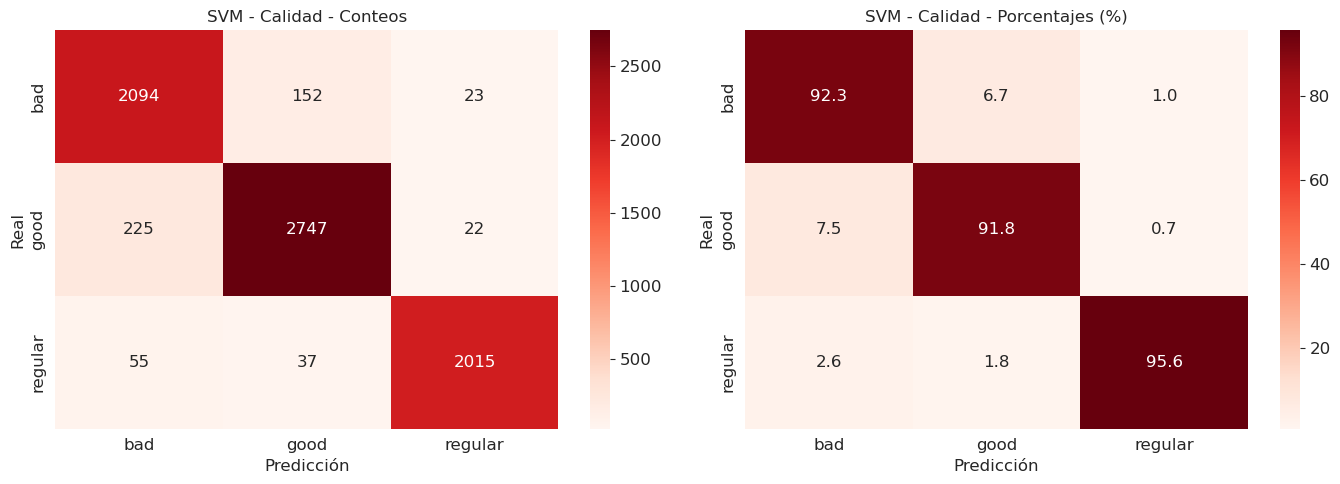

In [33]:
plot_confusion_matrix_full(y_quality_test, y_quality_pred, class_names_quality, "SVM - Calidad")

La matriz de confusión confirma el alto desempeño del modelo SVM, con tasas de acierto superiores al 91% en las tres categorías de calidad. La clase **regular** presentó el mejor resultado, alcanzando una tasa de clasificación correcta cercana al 96%.

Los errores observados se concentran principalmente entre las clases **good** y **bad**, lo que sugiere la existencia de características visuales compartidas que dificultan su separación mediante variables estadísticas de color y forma. Sin embargo, la baja proporción de confusiones demuestra que el modelo es capaz de distinguir adecuadamente la mayoría de los casos.

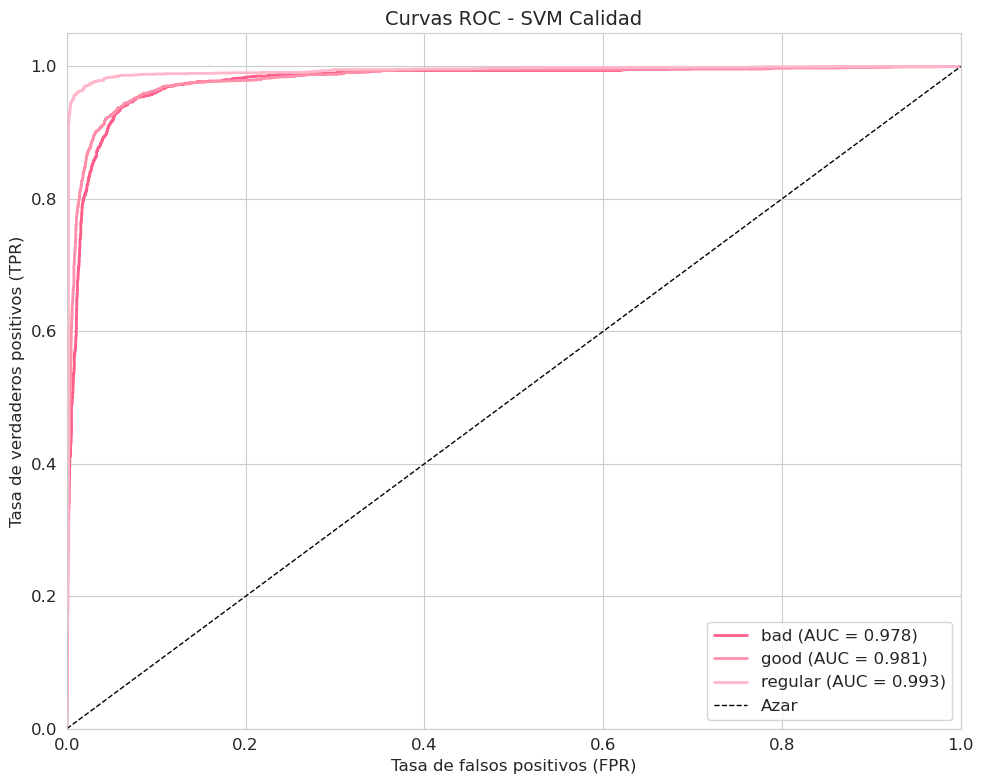

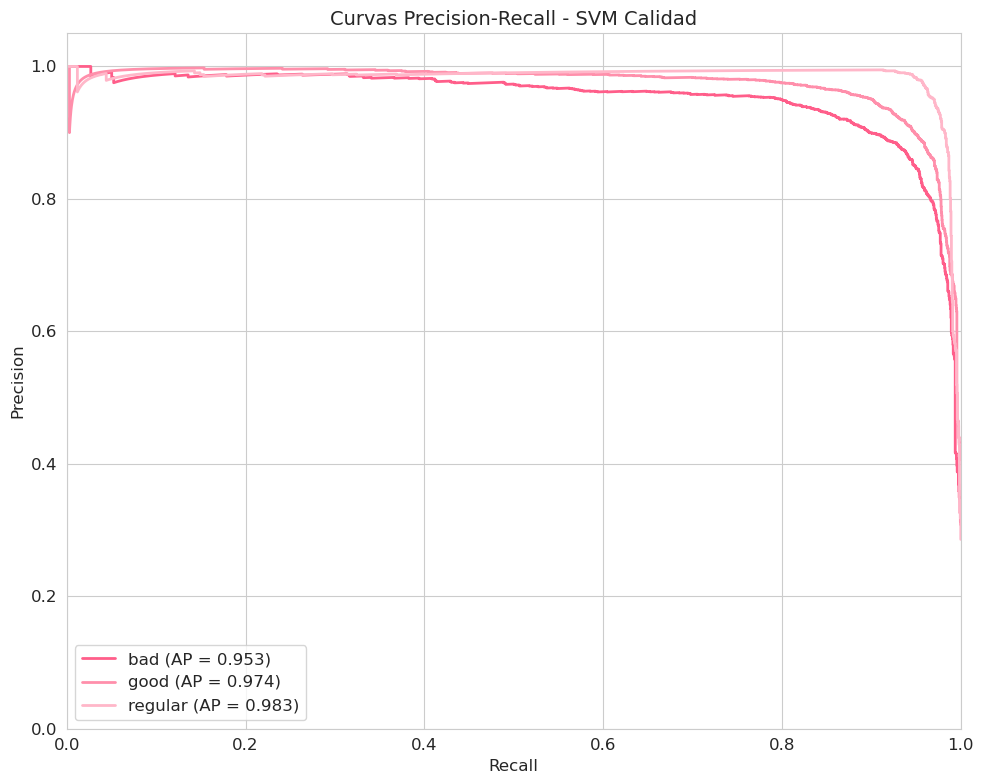

In [34]:
plot_roc_curves(y_quality_test, y_quality_proba, class_names_quality, "Curvas ROC - SVM Calidad")
plot_precision_recall_curves(y_quality_test, y_quality_proba, class_names_quality, "Curvas Precision-Recall - SVM Calidad")

Las curvas ROC y Precision-Recall permiten evaluar el comportamiento del modelo SVM bajo diferentes umbrales de decisión. Los resultados obtenidos muestran valores de **AUC superiores a 0.97 para todas las clases**, evidenciando una excelente capacidad de discriminación entre las distintas categorías de calidad.

- De manera complementaria, las curvas Precision-Recall presentan valores elevados de precisión promedio, manteniéndose estables a lo largo de gran parte del rango de *Recall*. Esto indica que el modelo conserva una alta calidad en sus predicciones positivas incluso cuando se incrementa la cantidad de muestras detectadas.

En conjunto, ambas métricas confirman la robustez y capacidad de generalización del clasificador. Sin embargo, la ligera disminución de precisión observada para valores muy altos de *Recall* sugiere la existencia de algunos casos límite que podrían beneficiarse de modelos capaces de capturar información espacial más compleja, como las redes neuronales convolucionales.


In [39]:
class_names_size = ['pequeño', 'mediano', 'grande']

print("EVALUACIÓN SVM - CLASIFICACIÓN DE TAMAÑO")

size_results = evaluate_model_full(
    y_size_test, y_size_pred, y_size_proba,
    model_name="SVM - Tamaño",
    class_names=class_names_size
)

EVALUACIÓN SVM - CLASIFICACIÓN DE TAMAÑO
SVM - Tamaño
Precision Macro:    0.9590
Recall Macro:       0.9594
F1-Score Macro:     0.9590
Precision Weighted: 0.9602
Recall Weighted:    0.9596
F1-Score Weighted:  0.9597
Cohen's Kappa:      0.9387
MCC:                0.9389
Balanced Accuracy:  0.9594
AUC-ROC Macro:      0.9929

Reporte por clase:
              precision    recall  f1-score   support

     pequeño       0.98      0.96      0.97      2903
     mediano       0.93      0.96      0.94      2440
      grande       0.97      0.96      0.96      2027

    accuracy                           0.96      7370
   macro avg       0.96      0.96      0.96      7370
weighted avg       0.96      0.96      0.96      7370



El modelo SVM optimizado fue evaluado sobre el conjunto de prueba para la tarea de clasificación de tamaño, obteniendo un **Accuracy del 96%** y un **F1-Score Macro de 0.9590**. Estos resultados reflejan un desempeño sobresaliente y una capacidad de generalización consistente entre las tres categorías de tamaño.

- Las métricas complementarias, como el **MCC (0.9389)** y el **índice Kappa (0.9387)**, evidencian un alto nivel de concordancia entre las predicciones y las etiquetas reales, mientras que el **AUC-ROC Macro de 0.9929** confirma una excelente separación entre clases.
- A nivel individual, las categorías **pequeño** y **grande** alcanzaron los mejores resultados, mientras que la clase **mediano** presentó una ligera reducción en precisión debido a que se encuentra entre los límites de las otras dos categorías. Sin embargo, su desempeño continuó siendo elevado, con un F1-Score superior a 0.94.

En general, los resultados muestran que las características geométricas utilizadas permiten describir adecuadamente el tamaño de las frutas, convirtiendo al SVM en una solución eficiente y precisa para esta tarea de clasificación.


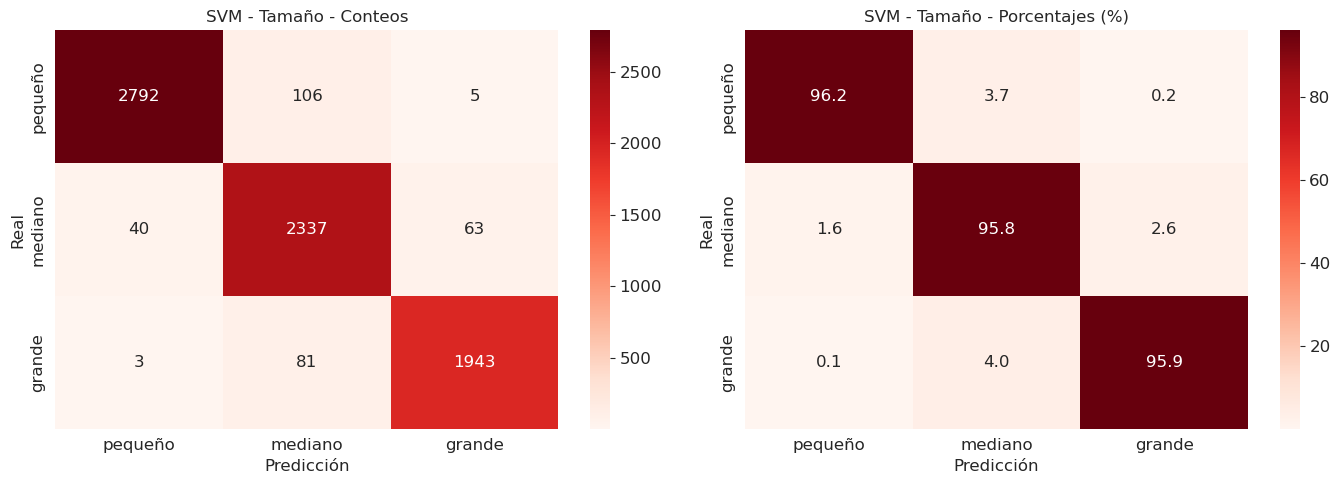

In [40]:
plot_confusion_matrix_full(y_size_test, y_size_pred, class_names_size, "SVM - Tamaño")

La matriz de confusión confirma el excelente desempeño del modelo SVM en la clasificación de tamaño, con tasas de acierto superiores al 95% en las categorías **pequeño**, **mediano** y **grande**. La mayoría de las predicciones se concentran en la diagonal principal, evidenciando una correcta separación entre las clases.

- Los errores observados son mínimos y se producen casi exclusivamente entre categorías adyacentes, especialmente entre **pequeño-mediano** y **mediano-grande**. Este comportamiento es esperado, ya que el tamaño es una variable originalmente continua que fue discretizada en intervalos.
- Además, las confusiones entre los extremos (**pequeño** y **grande**) son prácticamente inexistentes, lo que demuestra que las características geométricas utilizadas permiten distinguir adecuadamente las diferencias de escala entre frutas.

En conjunto, la matriz de confusión respalda la solidez del modelo y confirma que el enfoque basado en características geométricas resulta altamente efectivo para la clasificación de tamaño.


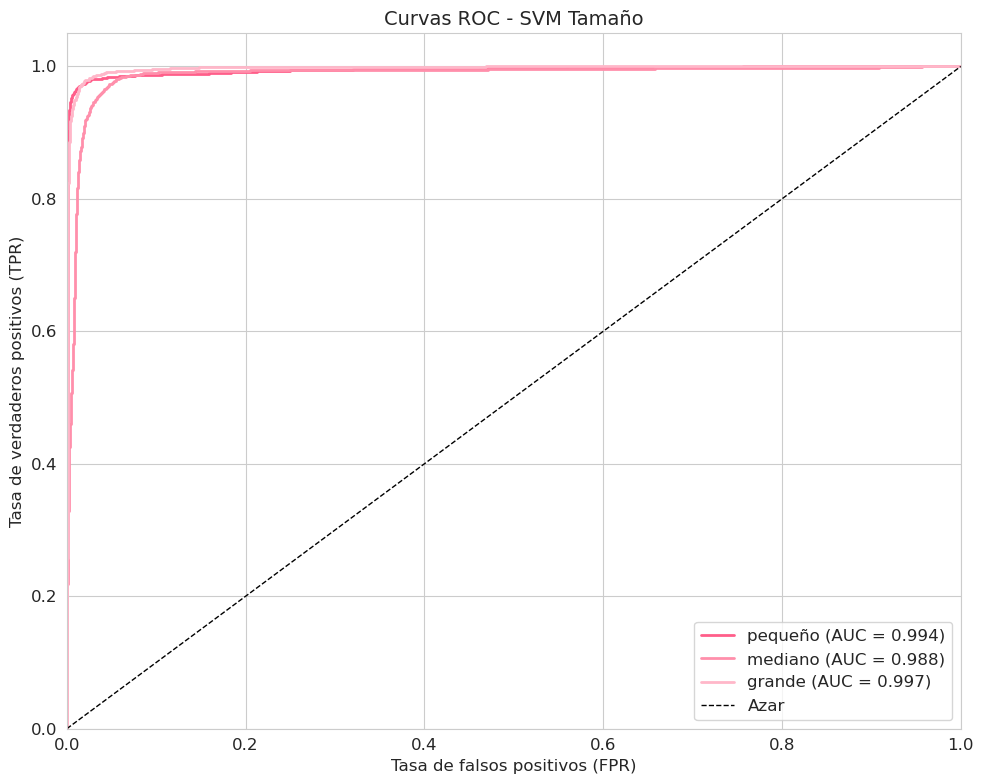

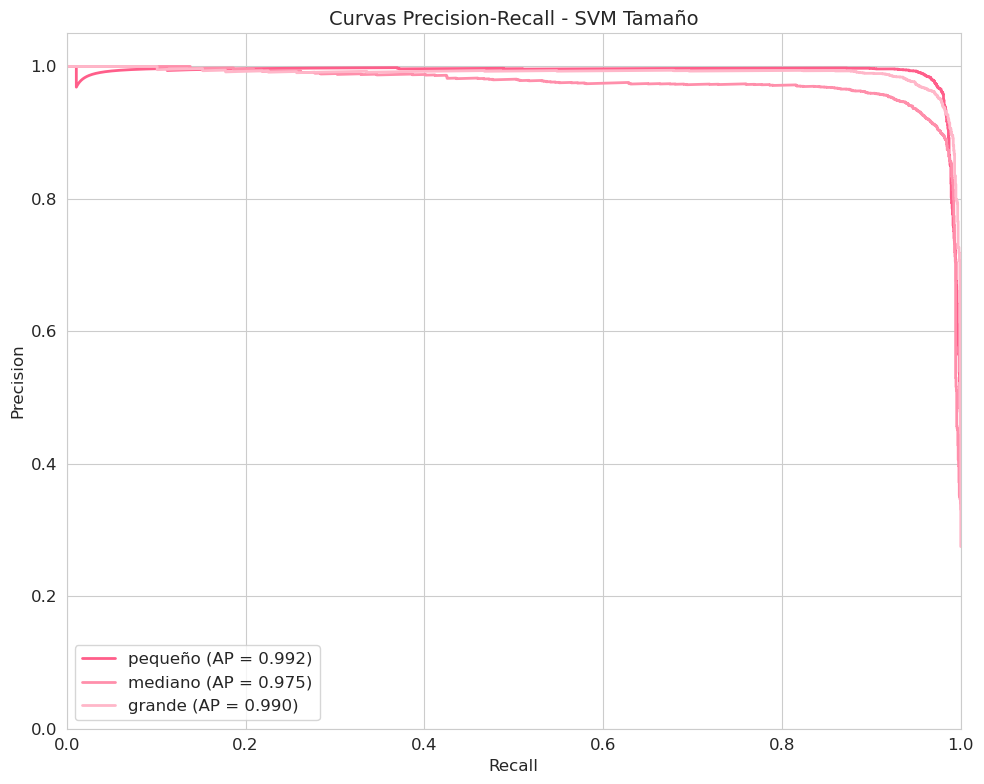

In [41]:
plot_roc_curves(y_size_test, y_size_proba, class_names_size, "Curvas ROC - SVM Tamaño")
plot_precision_recall_curves(y_size_test, y_size_proba, class_names_size, "Curvas Precision-Recall - SVM Tamaño")

Las curvas ROC y Precision-Recall evidencian el desempeño del modelo SVM en la clasificación de tamaño. Los valores de **AUC-ROC superiores a 0.98** para todas las categorías indican una capacidad de discriminación prácticamente perfecta entre las clases **pequeño**, **mediano** y **grande**.

- De forma complementaria, las curvas Precision-Recall presentan valores de precisión promedio cercanos a 1.0 y mantienen una gran estabilidad a medida que aumenta el *Recall*. Esto demuestra que el modelo puede identificar correctamente la mayoría de las muestras sin generar una cantidad significativa de falsos positivos.

Los resultados obtenidos confirman que las características geométricas empleadas proporcionan una representación altamente informativa del tamaño de las frutas, permitiendo al SVM construir fronteras de decisión precisas y robustas. En conjunto, ambas curvas respaldan la capacidad de generalización del modelo y validan su uso para la clasificación automática de tamaño.

Las curvas de aprendizaje permiten evaluar la capacidad de generalización del modelo SVM a medida que aumenta la cantidad de datos de entrenamiento. En ambas tareas, las curvas de entrenamiento y validación convergen de forma estable, manteniendo una diferencia reducida entre sus puntuaciones finales.

Curva de aprendizaje - calidad


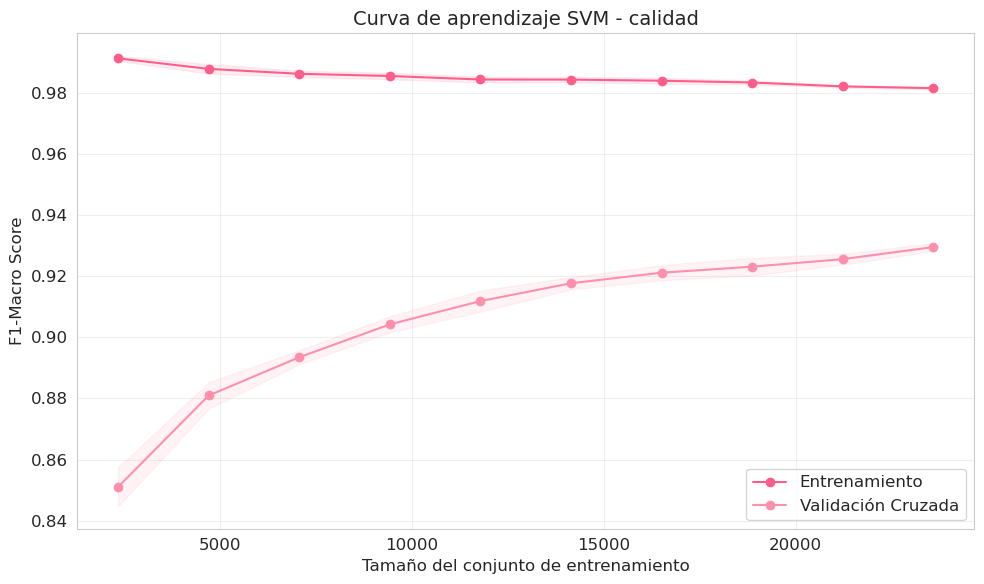

Curva de aprendizaje - tamaño


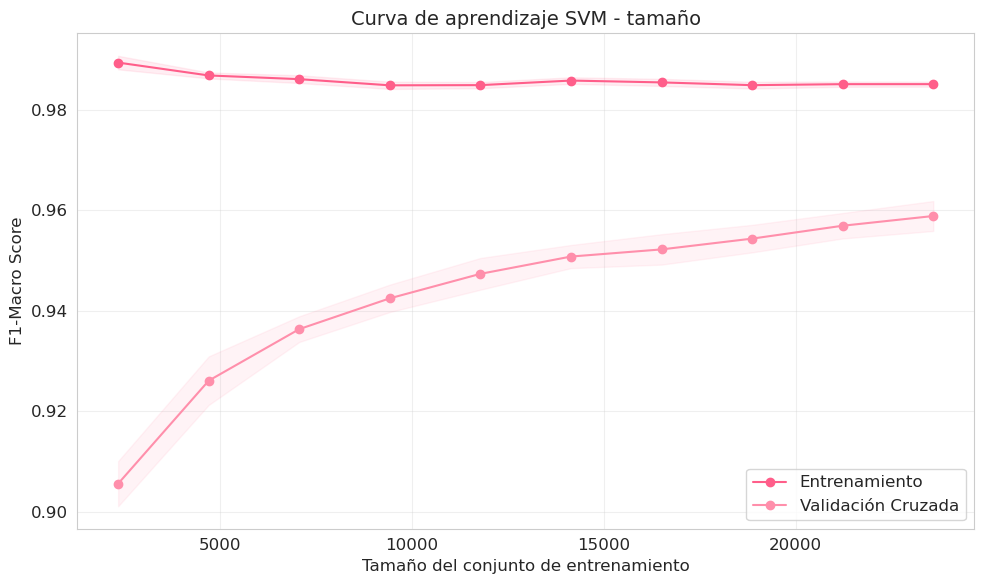

In [38]:
def plot_learning_curve(model, X, y, title="Curva de aprendizaje"):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1_macro'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.1, color=COLOR_PRIMARY)
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                    alpha=0.1, color=COLOR_SECONDARY)
    ax.plot(train_sizes, train_mean, 'o-', color=COLOR_PRIMARY, label='Entrenamiento')
    ax.plot(train_sizes, test_mean, 'o-', color=COLOR_SECONDARY, label='Validación Cruzada')
    
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('F1-Macro Score')
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Curva de aprendizaje - calidad")
plot_learning_curve(final_svm_quality, X_train, y_quality_train, "Curva de aprendizaje SVM - calidad")

print("Curva de aprendizaje - tamaño")
plot_learning_curve(final_svm_size, X_train, y_size_train, "Curva de aprendizaje SVM - tamaño")

Para la clasificación de calidad, el modelo alcanza valores elevados tanto en entrenamiento como en validación, lo que indica una buena capacidad para aprender patrones relevantes sin presentar señales significativas de sobreajuste. De manera similar, la tarea de clasificación de tamaño muestra una convergencia aún más cercana entre ambas curvas, reflejando un comportamiento altamente estable y consistente.

Además, se observa que las curvas de validación continúan mejorando ligeramente a medida que se incorporan más muestras de entrenamiento. Esto sugiere que el modelo podría beneficiarse de una mayor cantidad de datos, aunque el rendimiento actual ya evidencia una adecuada capacidad de generalización sobre datos no vistos durante el entrenamiento.

### Conclusiones

El análisis de errores permite identificar las principales limitaciones del modelo SVM en ambas tareas de clasificación.

In [43]:
def analyze_errors_detailed(y_true, y_pred, X_test_df, feature_names, class_names, title="Análisis de errores"):
    errors = y_true != y_pred
    error_rate = errors.mean()
    
    print(f"\n{title}")
    print(f"Tasa de error: {error_rate:.4f} ({errors.sum()} muestras)")
    
    # Matriz de confusión normalizada
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    print("\nConfusiones más comunes:")
    confusion_pairs = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm_norm[i, j] > 0.05:
                confusion_pairs.append((class_names[i], class_names[j], cm_norm[i, j]))
                print(f"  {class_names[i]} → {class_names[j]}: {cm_norm[i, j]:.2%}")
    
    # Estadísticas por clase
    print("\nEstadísticas por clase:")
    for i, class_name in enumerate(class_names):
        class_mask = y_true == i
        class_errors = errors[class_mask]
        error_class_rate = class_errors.mean() if class_mask.sum() > 0 else 0
        print(f"  {class_name}: {error_class_rate:.2%} error")

X_test_df = pd.DataFrame(X_test, columns=feature_cols)

analyze_errors_detailed(y_quality_test, y_quality_pred, X_test_df, feature_cols, class_names_quality, "Errores SVM - Calidad")
analyze_errors_detailed(y_size_test, y_size_pred, X_test_df, feature_cols, class_names_size, "Errores SVM - Tamaño")


Errores SVM - Calidad
Tasa de error: 0.0697 (514 muestras)

Confusiones más comunes:
  bad → good: 6.70%
  good → bad: 7.52%

Estadísticas por clase:
  bad: 7.71% error
  good: 8.25% error
  regular: 4.37% error

Errores SVM - Tamaño
Tasa de error: 0.0404 (298 muestras)

Confusiones más comunes:

Estadísticas por clase:
  pequeño: 3.82% error
  mediano: 4.22% error
  grande: 4.14% error


Para la clasificación de calidad, el modelo obtuvo una tasa de error global del 6.97%, concentrándose principalmente en las confusiones entre las categorías good y bad. Este comportamiento sugiere que ciertas variaciones de color e iluminación generan patrones similares entre frutas sanas y dañadas, dificultando su correcta diferenciación mediante características estadísticas agregadas.

En la clasificación de tamaño, la tasa de error se redujo al 4.04%, con una distribución homogénea entre las tres categorías. Los errores observados se producen principalmente entre tamaños adyacentes, un comportamiento esperado al discretizar una variable originalmente continua.

En conjunto, los resultados muestran que el SVM ofrece un desempeño muy sólido en ambas tareas. Sin embargo, las confusiones residuales observadas en la clasificación de calidad justifican la evaluación de modelos más avanzados, capaces de capturar información espacial y textural directamente desde las imágenes.

In [31]:
models_dir = Path("..") / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(final_svm_quality, models_dir / 'svm_quality.pkl')
joblib.dump(final_svm_size, models_dir / 'svm_size.pkl')
joblib.dump(le_quality, models_dir / 'label_encoder_quality.pkl')
joblib.dump(le_size, models_dir / 'label_encoder_size.pkl')

print("Modelos guardados en carpeta 'models/'")

svm_results = {
    'calidad': {
        'best_params': random_search_quality.best_params_,
        'best_cv_score': random_search_quality.best_score_,
        'test_f1_macro': quality_results['f1_macro'],
        'test_mcc': quality_results['mcc'],
        'test_kappa': quality_results['cohen_kappa'],
        'test_balanced_accuracy': quality_results['balanced_accuracy']
    },
    'tamaño': {
        'best_params': random_search_size.best_params_,
        'best_cv_score': random_search_size.best_score_,
        'test_f1_macro': size_results['f1_macro'],
        'test_mcc': size_results['mcc'],
        'test_kappa': size_results['cohen_kappa'],
        'test_balanced_accuracy': size_results['balanced_accuracy']
    }
}

with open(ANNOTATIONS_DIR / 'svm_results.json', 'w') as f:
    json.dump(svm_results, f, indent=2)

print("Resultados guardados en data/annotations/svm_results.json")

Modelos guardados en carpeta 'models/'
Resultados guardados en data/annotations/svm_results.json


La evaluación del modelo SVM evidenció una mejora significativa frente a los modelos base, alcanzando resultados superiores al 93% en calidad y al 96% en tamaño. Estos resultados validan la efectividad de la etapa de preparación de datos, particularmente el uso de características cromáticas derivadas del espacio HSV y la incorporación de variables geométricas relacionadas con el tamaño de las frutas.

Para la tarea de clasificación de tamaño, el modelo obtuvo un desempeño sobresaliente, con métricas consistentes en todas las clases y una tasa de error reducida. Los errores observados se concentraron únicamente en muestras cercanas a los límites entre categorías adyacentes, lo que indica que la estrategia basada en área normalizada resulta suficiente para resolver este problema de manera precisa y eficiente.

En la clasificación de calidad también se alcanzó un rendimiento alto, logrando una correcta identificación de la mayoría de las frutas. Sin embargo, el análisis de errores mostró que las principales confusiones ocurren entre las clases **good** y **bad**, especialmente en situaciones donde las condiciones de iluminación alteran la apariencia visual de la fruta. Esto evidencia una limitación inherente al uso de descriptores estadísticos globales, los cuales no capturan adecuadamente patrones locales de textura o defectos superficiales.

Finalmente, las curvas de aprendizaje mostraron un comportamiento estable y sin indicios importantes de sobreajuste, confirmando una adecuada capacidad de generalización. **No obstante, las limitaciones observadas en la clasificación de calidad justifican continuar con la siguiente fase del proyecto mediante modelos de deep learning, específicamente redes neuronales convolucionales (CNN), las cuales permitirán aprovechar directamente la información espacial de las imágenes para mejorar la detección de defectos y reducir las confusiones identificadas en esta etapa.**
